<a href="https://colab.research.google.com/github/Zeeba1705/atml_PA0/blob/main/Task2_ViT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 2: Vision Transformers

###2.1: Using a Pre-trained ViT

In [ ]:
import torch
import matplotlib.pyplot as plt

from PIL import Image
from transformers import ViTImageProcessor, ViTForImageClassification

device= torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [2]:
#decided to use huggingface ViT-Base/16

model_name = "google/vit-base-patch16-224"

#to prep test images in the same way images used to train this model were prepped
proc= ViTImageProcessor.from_pretrained(model_name)

model= ViTForImageClassification.from_pretrained(model_name)

model= model.to(device)
model.eval()

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

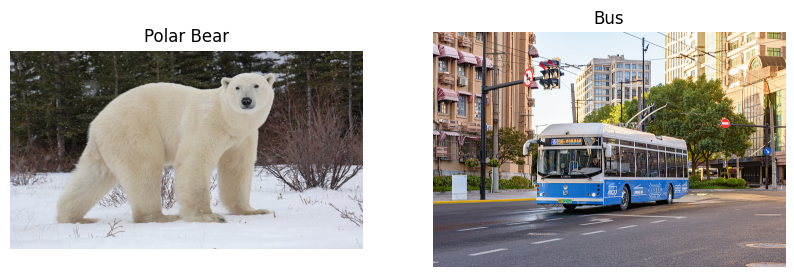

In [4]:
bear_img= Image.open("polar_bear.avif").convert("RGB")
bus_img= Image.open("bus.jpg").convert("RGB")

images = [bear_img, bus_img]

fig,axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(bear_img)
axes[0].set_title("Polar Bear")
axes[0].axis("off")

axes[1].imshow(bus_img)
axes[1].set_title("Bus")
axes[1].axis("off")

plt.show()

In [5]:
inputs= proc(images=images, return_tensors="pt")

inputs= {key: value.to(device) for key,value in inputs.items()}

In [6]:
print(inputs["pixel_values"].shape)

torch.Size([2, 3, 224, 224])


In [7]:
with torch.no_grad():
  outs=model(**inputs)

logits=outs.logits



In [8]:
preds=logits.argmax(dim=1)

for i, predicted in enumerate(preds):
    label= model.config.id2label[predicted.item()]
    print(f"Image {i + 1}: {label}")

Image 1: ice bear, polar bear, Ursus Maritimus, Thalarctos maritimus
Image 2: trolleybus, trolley coach, trackless trolley


Model predicted polar bear for the first image and trolleybus for the second, successful!



---



###Task 2.2: Visualizing Patch Attention

In [10]:
model = ViTForImageClassification.from_pretrained(
    model_name,
    attn_implementation="eager"
)

model = model.to(device)
model.eval()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

In [11]:
with torch.no_grad():
    outputs= model(**inputs, output_attentions=True)

attentions= outputs.attentions

print(len(attentions))

#final transformer layer, attention matrix
print(attentions[-1].shape)

12
torch.Size([2, 12, 197, 197])




*   batch_size = 2
*   no. of attention heads= 12
* seq_len = 197 (1 CLS token + 196 patch tokens)
   





In [13]:
final_atten= attentions[-1]

cls_atten = final_atten[:, :, 0, 1:]

In [16]:
#computing the avg over attention heads and then reshaping to 14x14 attention maps

cls_atten_mean= cls_atten.mean(dim=1)

print(cls_atten_mean.shape)

attention_maps= cls_atten_mean.reshape(2, 14, 14)

print(attention_maps.shape)

torch.Size([2, 196])
torch.Size([2, 14, 14])


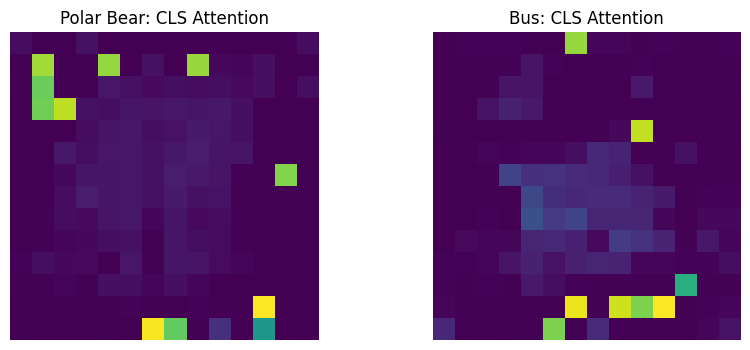

In [17]:
fig, axes= plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(attention_maps[0].cpu())
axes[0].set_title("Polar Bear: CLS Attention")
axes[0].axis("off")

axes[1].imshow(attention_maps[1].cpu())
axes[1].set_title("Bus: CLS Attention")
axes[1].axis("off")

plt.show()

In [19]:
#need to go from 14x14 to 224x224 as ViT input is 224x224

import torch.nn.functional as F

attention_upsampled= F.interpolate(attention_maps.unsqueeze(1), size=(224, 224),
    mode="bilinear", align_corners=False)

attention_upsampled= attention_upsampled.squeeze(1)

print(attention_upsampled.shape)

torch.Size([2, 224, 224])


In [20]:
attention_norm = []

for i in range(attention_upsampled.shape[0]):
    attn= attention_upsampled[i]
    attn= attn - attn.min()
    attn= attn / attn.max()
    attention_norm.append(attn)

attention_norm = torch.stack(attention_norm)

print(attention_norm.shape)

torch.Size([2, 224, 224])


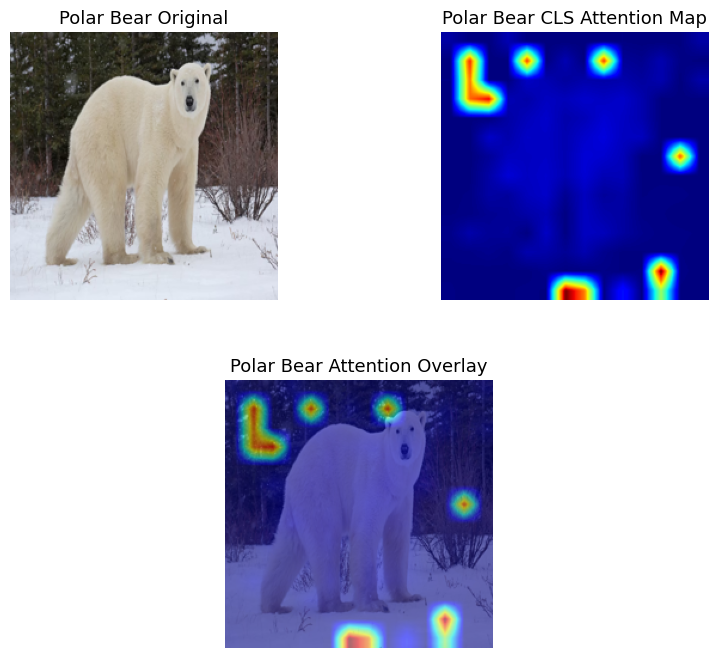

In [32]:
ffig, axes = plt.subplot_mosaic(
    [
        ["orig", "attn"],
        ["overlay", "overlay"]
    ], figsize=(10, 8), gridspec_kw={"hspace": 0.3, "wspace": 0.25}
)

bear_resized = bear_img.resize((224, 224))

axes["orig"].imshow(bear_resized)
axes["orig"].set_title("Polar Bear Original", fontsize=13)
axes["orig"].axis("off")

axes["attn"].imshow(attention_norm[0].cpu(), cmap="jet")
axes["attn"].set_title("Polar Bear CLS Attention Map", fontsize=13)
axes["attn"].axis("off")

axes["overlay"].imshow(bear_resized)
axes["overlay"].imshow(attention_norm[0].cpu(), cmap="jet", alpha=0.55)
axes["overlay"].set_title("Polar Bear Attention Overlay", fontsize=13)
axes["overlay"].axis("off")

plt.show()

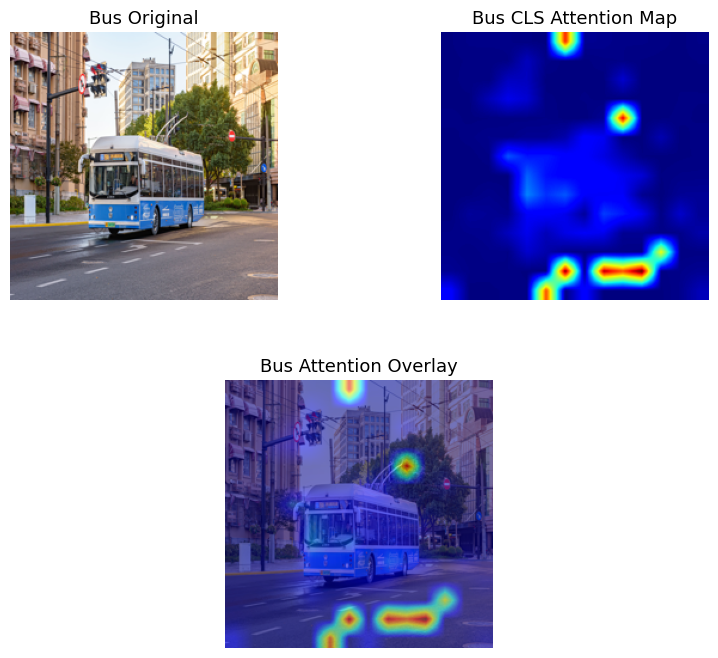

In [34]:
fig, axes = plt.subplot_mosaic(
    [
        ["orig", "attn"],
        ["overlay", "overlay"]
    ],
    figsize=(10, 8),
    gridspec_kw={"hspace": 0.3, "wspace": 0.25}
)

bus_resized = bus_img.resize((224, 224))

axes["orig"].imshow(bus_resized)
axes["orig"].set_title("Bus Original", fontsize=13)
axes["orig"].axis("off")

axes["attn"].imshow(attention_norm[1].cpu(), cmap="jet")
axes["attn"].set_title("Bus CLS Attention Map", fontsize=13)
axes["attn"].axis("off")

axes["overlay"].imshow(bus_resized)
axes["overlay"].imshow(attention_norm[1].cpu(), cmap="jet", alpha=0.55)
axes["overlay"].set_title("Bus Attention Overlay", fontsize=13)
axes["overlay"].axis("off")

plt.show()